In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv ('match_performance.csv')
data

,match_id,date,kickoff_time_utc,status,team,team_code,team_confederation,team_fifa_rank,team_elo,venue_side,...,saves,team_xg,goals_scored,opponent,opponent_code,opponent_fifa_rank,opponent_elo,stadium_name,city,elevation_meters
0,1,2026-06-11,19:00:00,Completed,Mexico,MEX,CONCACAF,14,1810,Home,...,1,1.84,2,South Africa,RSA,60,1620,Mexico City Stadium (Estadio Azteca),Mexico City,2200
1,25,2026-06-18,15:00:00,Completed,Mexico,MEX,CONCACAF,14,1810,Home,...,2,1.62,1,South Korea,KOR,22,1800,Atlanta Stadium (Mercedes-Benz Stadium),Atlanta,318
2,49,2026-06-24,18:00:00,Completed,Mexico,MEX,CONCACAF,14,1810,Away,...,1,1.27,3,Czechia,CZE,40,1740,Mexico City Stadium (Estadio Azteca),Mexico City,2200
3,1,2026-06-11,19:00:00,Completed,South Africa,RSA,CAF,60,1620,Away,...,4,0.52,0,Mexico,MEX,14,1810,Mexico City Stadium (Estadio Azteca),Mexico City,2200
4,26,2026-06-18,18:00:00,Completed,South Africa,RSA,CAF,60,1620,Away,...,4,1.15,1,Czechia,CZE,40,1740,Los Angeles Stadium (SoFi Stadium),Inglewood,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,47,2026-06-23,21:00:00,Completed,Ghana,GHA,CAF,49,1690,Away,...,3,0.89,0,England,ENG,4,2050,Seattle Stadium (Lumen Field),Seattle,3
122,72,2026-06-28,22:00:00,Completed,Ghana,GHA,CAF,49,1690,Away,...,2,0.74,1,Croatia,CRO,11,1940,Philadelphia Stadium (Lincoln Financial Field),Philadelphia,3
123,23,2026-06-17,21:00:00,Completed,Panama,PAN,CONCACAF,34,1680,Away,...,1,0.75,0,Ghana,GHA,49,1690,Houston Stadium (NRG Stadium),Houston,14
124,48,2026-06-23,23:59:00,Completed,Panama,PAN,CONCACAF,34,1680,Home,...,3,0.42,0,Croatia,CRO,11,1940,Mexico City Stadium (Estadio Azteca),Mexico City,2200


In [ ]:
team_performance = data.groupby('team').agg(
    total_xg=('team_xg', 'sum'),
    total_goals=('goals_scored', 'sum')
).reset_index()

print(team_performance)

                      team  total_xg  total_goals
0                  Algeria      3.96            5
1                Argentina      6.56            8
2                Australia      2.28            2
3                  Austria      3.97            6
4                  Belgium      3.03            1
5   Bosnia and Herzegovina      3.34            5
6                   Brazil      2.78            4
7               Cabo Verde      1.87            2
8                   Canada      7.84            9
9                 Colombia      5.34            4
10                Congo DR      4.08            4
11                 Croatia      3.54            5
12                 Curaçao      0.52            1
13                 Czechia      3.57            2
14           Côte d'Ivoire      1.82            2
15                 Ecuador      2.87            0
16                   Egypt      3.27            4
17                 England      5.43            6
18                  France      5.61           10


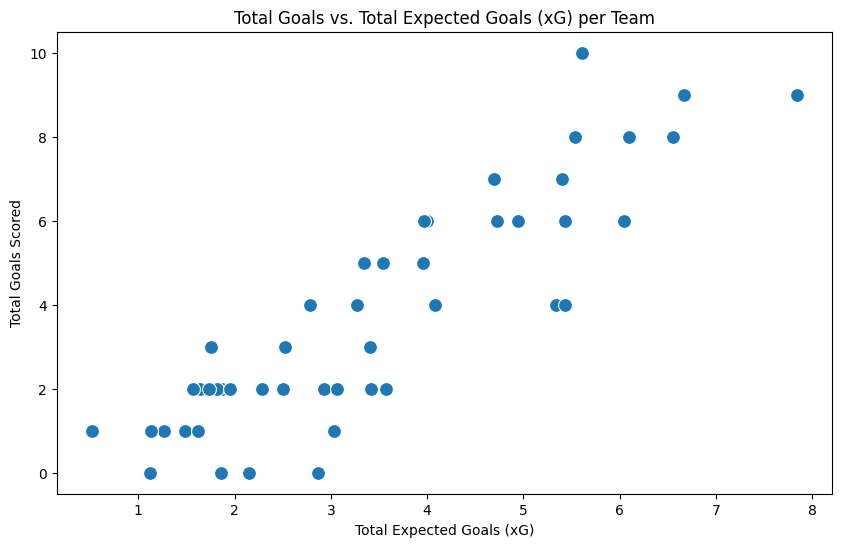

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=team_performance, x='total_xg', y='total_goals', s=100)
plt.title('Total Goals vs. Total Expected Goals (xG) per Team')
plt.xlabel('Total Expected Goals (xG)')
plt.ylabel('Total Goals Scored')
plt.show()

In [ ]:
team_total_xg = data.groupby('team')['team_xg'].sum().reset_index()
team_total_xg.rename(columns={'team_xg': 'total_xg_for'}, inplace=True)

xG_against_data = data.groupby('opponent')['team_xg'].sum().reset_index()
xG_against_data.rename(columns={'opponent': 'team', 'team_xg': 'total_xg_against'}, inplace=True)

# Merge the two dataframes to get total xG and xG against for each team
team_xg_summary = pd.merge(team_total_xg, xG_against_data, on='team', how='left')

print(team_xg_summary)

                      team  total_xg_for  total_xg_against
0                  Algeria          3.96              4.97
1                Argentina          6.56              1.73
2                Australia          2.28              2.48
3                  Austria          3.97              4.28
4                  Belgium          3.03              1.74
5   Bosnia and Herzegovina          3.34              4.75
6                   Brazil          2.78              2.00
7               Cabo Verde          1.87              4.18
8                   Canada          7.84              2.04
9                 Colombia          5.34              2.26
10                Congo DR          4.08              3.60
11                 Croatia          3.54              4.08
12                 Curaçao          0.52              6.74
13                 Czechia          3.57              3.87
14           Côte d'Ivoire          1.82              2.80
15                 Ecuador          2.87              1.

In [ ]:
!pip install adjustText

# XG Data Preparation

In [ ]:
match = pd.read_csv ('matches_detailed.csv')
match

,match_id,date,kickoff_time_utc,stage_name,stadium_name,city,country,home_team_name,home_fifa_code,away_team_name,away_fifa_code,home_score,away_score,status,home_xg,away_xg,home_goalkeeper,away_goalkeeper,player_of_the_match_name,referee_name
0,1,2026-06-11,19:00,Group Stage,Mexico City Stadium (Estadio Azteca),Mexico City,MEX,Mexico,MEX,South Africa,RSA,2.0,0.0,Completed,1.84,0.52,Francisco Guillermo Ochoa,Ronwen Hayden Williams,Julián Andrés Quinones,Szymon Marciniak
1,2,2026-06-11,23:00,Group Stage,Guadalajara Stadium (Estadio Akron),Zapopan,MEX,South Korea,KOR,Czechia,CZE,2.0,1.0,Completed,1.45,1.12,Seunggyu Kim,Mat ě j Kovar,Inbeom Hwang,Daniele Orsato
2,3,2026-06-12,19:00,Group Stage,Toronto Stadium (BMO Field),Toronto,CAN,Canada,CAN,Bosnia and Herzegovina,BIH,1.0,1.0,Completed,1.35,0.98,Maxime Crepeau,Nikola Vasilj,Ismaël Kenneth Jordan Kone,Michael Oliver
3,4,2026-06-12,23:00,Group Stage,Los Angeles Stadium (SoFi Stadium),Inglewood,USA,USA,USA,Paraguay,PAR,4.0,1.0,Completed,2.76,0.88,Matthew Charles Turner,Roberto Junior Fernandez,Folarin Jolaoluwa Balogun,Anthony Taylor
4,5,2026-06-13,15:00,Group Stage,Boston Stadium (Gillette Stadium),Foxborough,USA,Qatar,QAT,Switzerland,SUI,1.0,1.0,Completed,0.78,1.54,Ibrahim Mahmoud Abunada,Gregor Kobel,Ibrahim Mahmoud Abunada,Clément Turpin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,85,2026-07-03,09:00,Round of 32,Vancouver Stadium (BC Place),Vancouver,CAN,Switzerland,SUI,Algeria,ALG,NaN,NaN,Scheduled,NaN,NaN,NaN,NaN,NaN,Clément Turpin
85,86,2026-07-04,00:00,Round of 32,Dallas Stadium (AT&T Stadium),Arlington,USA,Australia,AUS,Egypt,EGY,NaN,NaN,Scheduled,NaN,NaN,NaN,NaN,NaN,Danny Makkelie
86,87,2026-07-04,04:00,Round of 32,Miami Stadium (Hard Rock Stadium),Miami Gardens,USA,Argentina,ARG,Cabo Verde,CPV,NaN,NaN,Scheduled,NaN,NaN,NaN,NaN,NaN,Jesús Valenzuela
87,88,2026-07-04,07:30,Round of 32,Kansas City Stadium (Arrowhead Stadium),Kansas City,USA,Colombia,COL,Ghana,GHA,NaN,NaN,Scheduled,NaN,NaN,NaN,NaN,NaN,Wilton Sampaio


## Filter for group stage

In [ ]:
group = match[match['stage_name'] == 'Group Stage'].copy()
group.head()

,match_id,date,kickoff_time_utc,stage_name,stadium_name,city,country,home_team_name,home_fifa_code,away_team_name,away_fifa_code,home_score,away_score,status,home_xg,away_xg,home_goalkeeper,away_goalkeeper,player_of_the_match_name,referee_name
0,1,2026-06-11,19:00,Group Stage,Mexico City Stadium (Estadio Azteca),Mexico City,MEX,Mexico,MEX,South Africa,RSA,2.0,0.0,Completed,1.84,0.52,Francisco Guillermo Ochoa,Ronwen Hayden Williams,Julián Andrés Quinones,Szymon Marciniak
1,2,2026-06-11,23:00,Group Stage,Guadalajara Stadium (Estadio Akron),Zapopan,MEX,South Korea,KOR,Czechia,CZE,2.0,1.0,Completed,1.45,1.12,Seunggyu Kim,Mat ě j Kovar,Inbeom Hwang,Daniele Orsato
2,3,2026-06-12,19:00,Group Stage,Toronto Stadium (BMO Field),Toronto,CAN,Canada,CAN,Bosnia and Herzegovina,BIH,1.0,1.0,Completed,1.35,0.98,Maxime Crepeau,Nikola Vasilj,Ismaël Kenneth Jordan Kone,Michael Oliver
3,4,2026-06-12,23:00,Group Stage,Los Angeles Stadium (SoFi Stadium),Inglewood,USA,USA,USA,Paraguay,PAR,4.0,1.0,Completed,2.76,0.88,Matthew Charles Turner,Roberto Junior Fernandez,Folarin Jolaoluwa Balogun,Anthony Taylor
4,5,2026-06-13,15:00,Group Stage,Boston Stadium (Gillette Stadium),Foxborough,USA,Qatar,QAT,Switzerland,SUI,1.0,1.0,Completed,0.78,1.54,Ibrahim Mahmoud Abunada,Gregor Kobel,Ibrahim Mahmoud Abunada,Clément Turpin


## Filter columns

In [ ]:
teams = group[['home_team_name', 'away_team_name', 'home_score', 'away_score', 'home_xg', 'away_xg']].copy()
teams

,home_team_name,away_team_name,home_score,away_score,home_xg,away_xg
0,Mexico,South Africa,2.0,0.0,1.84,0.52
1,South Korea,Czechia,2.0,1.0,1.45,1.12
2,Canada,Bosnia and Herzegovina,1.0,1.0,1.35,0.98
3,USA,Paraguay,4.0,1.0,2.76,0.88
4,Qatar,Switzerland,1.0,1.0,0.78,1.54
...,...,...,...,...,...,...
67,Algeria,Austria,3.0,3.0,1.62,1.44
68,Colombia,Portugal,0.0,0.0,1.62,0.73
69,Congo DR,Uzbekistan,3.0,1.0,2.35,0.20
70,Panama,England,0.0,2.0,0.69,1.39


## Aggregate goals and xg for each teams

In [ ]:
import pandas as pd

# Prepare DataFrame for home team's conceded stats
home_conceded_stats = teams[['home_team_name', 'away_score', 'away_xg']].copy()
home_conceded_stats.rename(columns={'home_team_name': 'team_name', 'away_score': 'goals_conceded', 'away_xg': 'xga'}, inplace=True)

# Prepare DataFrame for away team's conceded stats
away_conceded_stats = teams[['away_team_name', 'home_score', 'home_xg']].copy()
away_conceded_stats.rename(columns={'away_team_name': 'team_name', 'home_score': 'goals_conceded', 'home_xg': 'xga'}, inplace=True)

# Concatenate and sum for total conceded stats per team
conceded_stats_summary = pd.concat([home_conceded_stats, away_conceded_stats]).groupby('team_name').sum().reset_index()

# Merge the new conceded stats with the existing team_stats_summary
team_stats_summary = pd.merge(team_stats_summary, conceded_stats_summary, on='team_name', how='left')

team_stats_summary

,team_name,goals,xg,team_confederation,goals_conceded_x,xga_x,goals_conceded_y,xga_y
0,Algeria,5,3.96,CAF,7,4.97,7,4.97
1,Argentina,8,6.56,CONMEBOL,1,1.73,1,1.73
2,Australia,2,2.28,AFC,2,2.48,2,2.48
3,Austria,6,3.97,UEFA,6,4.28,6,4.28
4,Belgium,6,6.28,UEFA,2,2.22,2,2.22
5,Bosnia and Herzegovina,5,3.34,UEFA,6,4.75,6,4.75
6,Brazil,7,4.96,CONMEBOL,1,2.45,1,2.45
7,Cabo Verde,2,1.87,CAF,2,4.18,2,4.18
8,Canada,8,6.52,CONCACAF,3,1.91,3,1.91
9,Colombia,4,5.34,CONMEBOL,1,2.26,1,2.26


# Plotting charts

### Total xG vs Total xGA

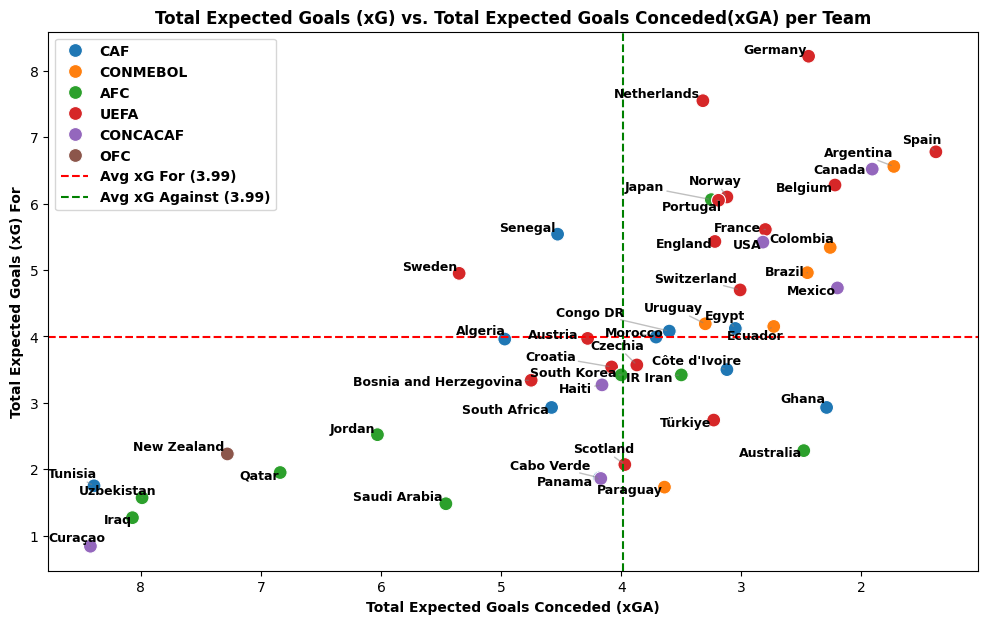

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

plt.figure(figsize=(12, 7))
sns.scatterplot(data=team_stats_summary, x='xga', y='xg', s=100, hue='team_confederation') # Swapped x and y and added hue

texts = []
# Label all teams and collect text objects
for index, row in team_stats_summary.iterrows():
    texts.append(plt.text(row['xga'], row['xg'], row['team_name'], fontsize=9,
                          fontfamily='Open Sans', fontweight='bold')) # Added font properties

# Adjust text to prevent overlapping
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))

plt.title('Total Expected Goals (xG) vs. Total Expected Goals Conceded(xGA) per Team',
          fontfamily='Open Sans', fontweight='bold') # Added font properties
plt.xlabel('Total Expected Goals Conceded (xGA)', fontfamily='Open Sans', fontweight='bold') # Added font properties
plt.ylabel('Total Expected Goals (xG) For', fontfamily='Open Sans', fontweight='bold') # Added font properties

# Calculate averages for reference lines
avg_xg_for = team_stats_summary['xg'].mean()
avg_xg_against = team_stats_summary['xga'].mean()

# Add reference lines
plt.axhline(avg_xg_for, color='red', linestyle='--', label=f'Avg xG For ({avg_xg_for:.2f})')
plt.axvline(avg_xg_against, color='green', linestyle='--', label=f'Avg xG Against ({avg_xg_against:.2f})')

# Invert the x-axis as it now represents 'goals conceded'
plt.gca().invert_xaxis()

# Set font properties for the legend
plt.legend(prop={'family': 'Open Sans', 'weight': 'bold'})
plt.show()

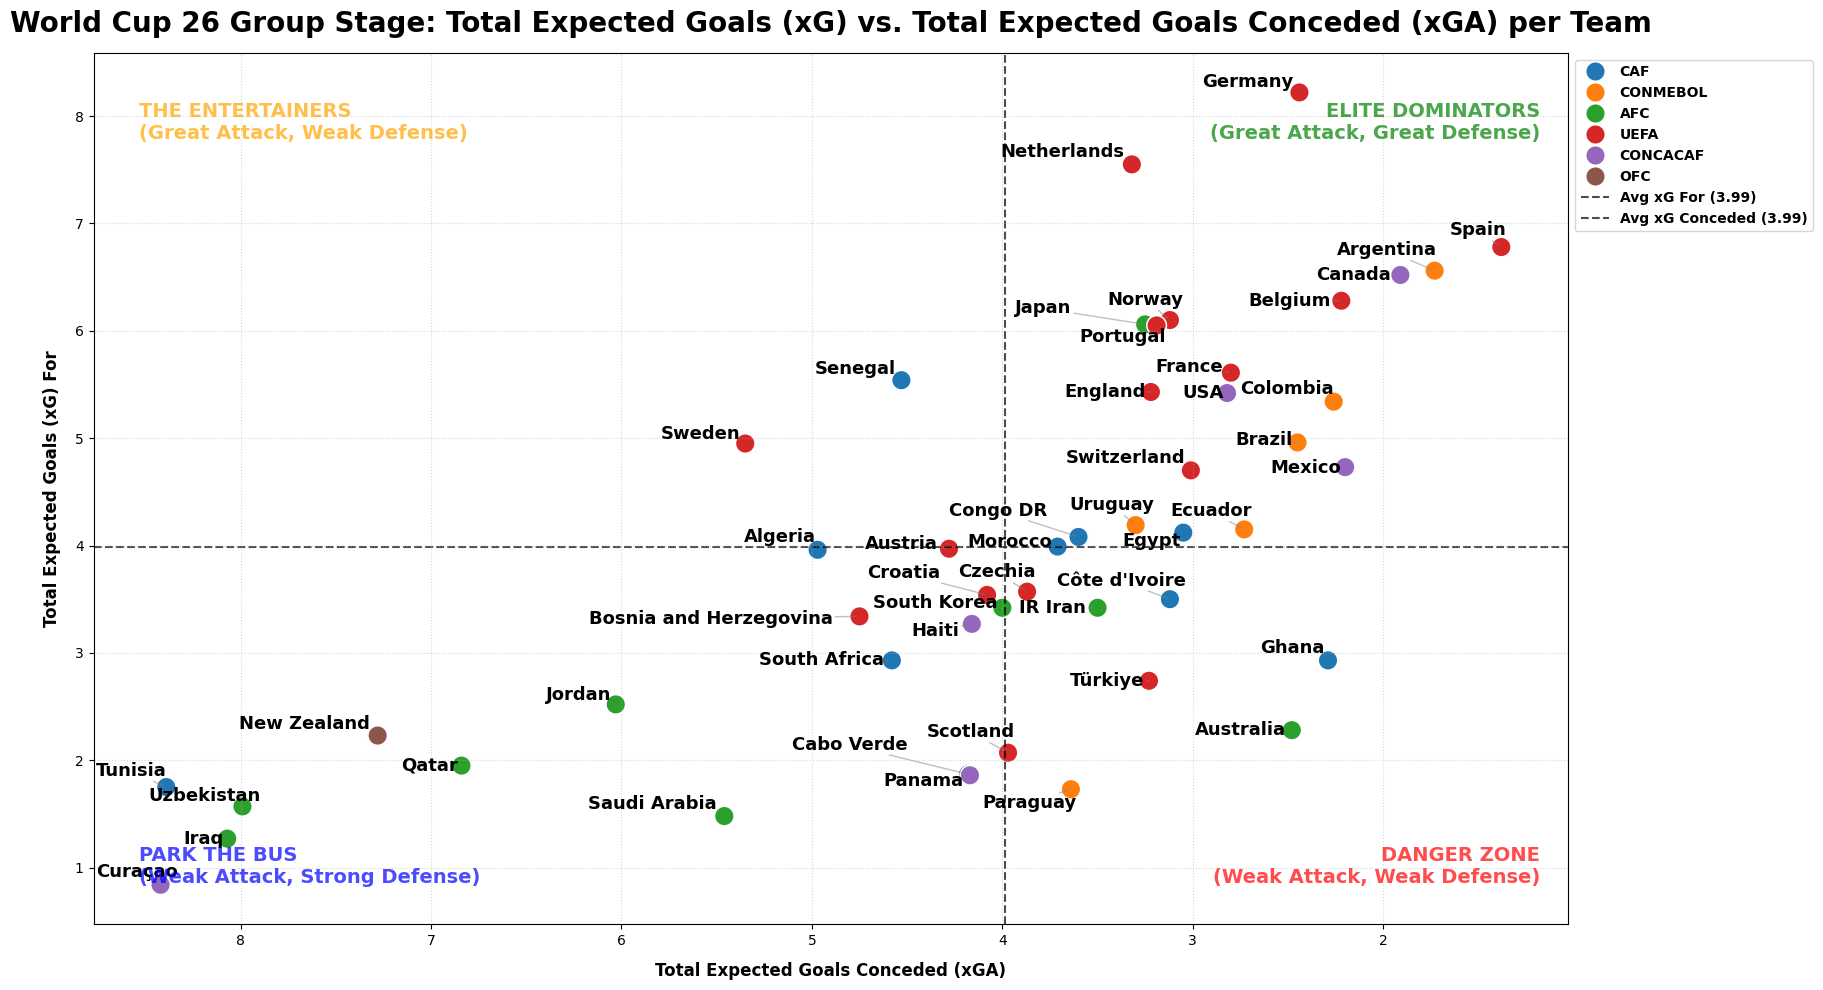

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

plt.figure(figsize=(18, 10)) # Increased overall figure size for a larger chart
sns.scatterplot(data=team_stats_summary, x='xga', y='xg', s=200, hue='team_confederation', zorder=1) # Increased point size to 200

texts = []
# Label all teams and collect text objects
for index, row in team_stats_summary.iterrows():
    texts.append(plt.text(row['xga'], row['xg'], row['team_name'], fontsize=13, # Kept font size at 12 as per previous request
                          fontfamily='Open Sans', fontweight='bold'))

# Adjust text to prevent overlapping
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))

plt.title('World Cup 26 Group Stage: Total Expected Goals (xG) vs. Total Expected Goals Conceded (xGA) per Team',
          fontfamily='Open Sans', fontweight='bold', fontsize=20, pad=15)
plt.xlabel('Total Expected Goals Conceded (xGA)', fontfamily='Open Sans', fontweight='bold', labelpad=10, fontsize=12)
plt.ylabel('Total Expected Goals (xG) For', fontfamily='Open Sans', fontweight='bold', labelpad=10, fontsize=12)

# Calculate averages for reference lines
avg_xg_for = team_stats_summary['xg'].mean()
avg_xg_against = team_stats_summary['xga'].mean()

# Add reference lines (Behind the points using zorder)
plt.axhline(avg_xg_for, color='black', linestyle='--', alpha=0.7, zorder=1, label=f'Avg xG For ({avg_xg_for:.2f})')
plt.axvline(avg_xg_against, color='black', linestyle='--', alpha=0.7, zorder=1, label=f'Avg xG Conceded ({avg_xg_against:.2f})')

# Invert the x-axis so low xGA (good defense) sits on the right
plt.gca().invert_xaxis()

# Get axis limits dynamically to place the quadrant labels perfectly in the corners
xmin, xmax = plt.xlim() # Note: xmin is larger than xmax because it's inverted!
ymin, ymax = plt.ylim()

# --- DYNAMIC QUADRANT LABELS (Matching your inverted X-axis) ---
# Top Right: High xG, Low xGA (Elite)
plt.text(xmin - (xmin-avg_xg_against)*0.05, ymax - (ymax-avg_xg_for)*0.1, 'THE ENTERTAINERS\n(Great Attack, Weak Defense)',
         fontsize=14, fontfamily='Open Sans', color='orange', alpha=0.7, fontweight='bold', ha='left', va='top')

# Bottom Right: Low xG, Low xGA (Defensive/Cagey)
plt.text(xmin - (xmin-avg_xg_against)*0.05, ymin + (avg_xg_for-ymin)*0.1, 'PARK THE BUS\n(Weak Attack, Strong Defense)',
         fontsize=14, fontfamily='Open Sans', color='blue', alpha=0.7, fontweight='bold', ha='left', va='bottom')

# Top Left: High xG, High xGA (Chaos/Entertainers)
plt.text(xmax + (avg_xg_against-xmax)*0.05, ymax - (ymax-avg_xg_for)*0.1, 'ELITE DOMINATORS\n(Great Attack, Great Defense)',
         fontsize=14, fontfamily='Open Sans', color='green', alpha=0.7, fontweight='bold', ha='right', va='top')

# Bottom Left: Low xG, High xGA (Danger Zone)
plt.text(xmax + (avg_xg_against-xmax)*0.05, ymin + (avg_xg_for-ymin)*0.1, 'DANGER ZONE\n(Weak Attack, Weak Defense)',
         fontsize=14, fontfamily='Open Sans', color='red', alpha=0.7, fontweight='bold', ha='right', va='bottom')

# Style the grid and layout
plt.grid(True, linestyle=':', alpha=0.5, zorder=0)
plt.legend(prop={'family': 'Open Sans', 'weight': 'bold', 'size': 10}, bbox_to_anchor=(1, 1), loc='upper left') # Changed 'fontsize' to 'size'
plt.tight_layout()

plt.show()

## xG vs xGA

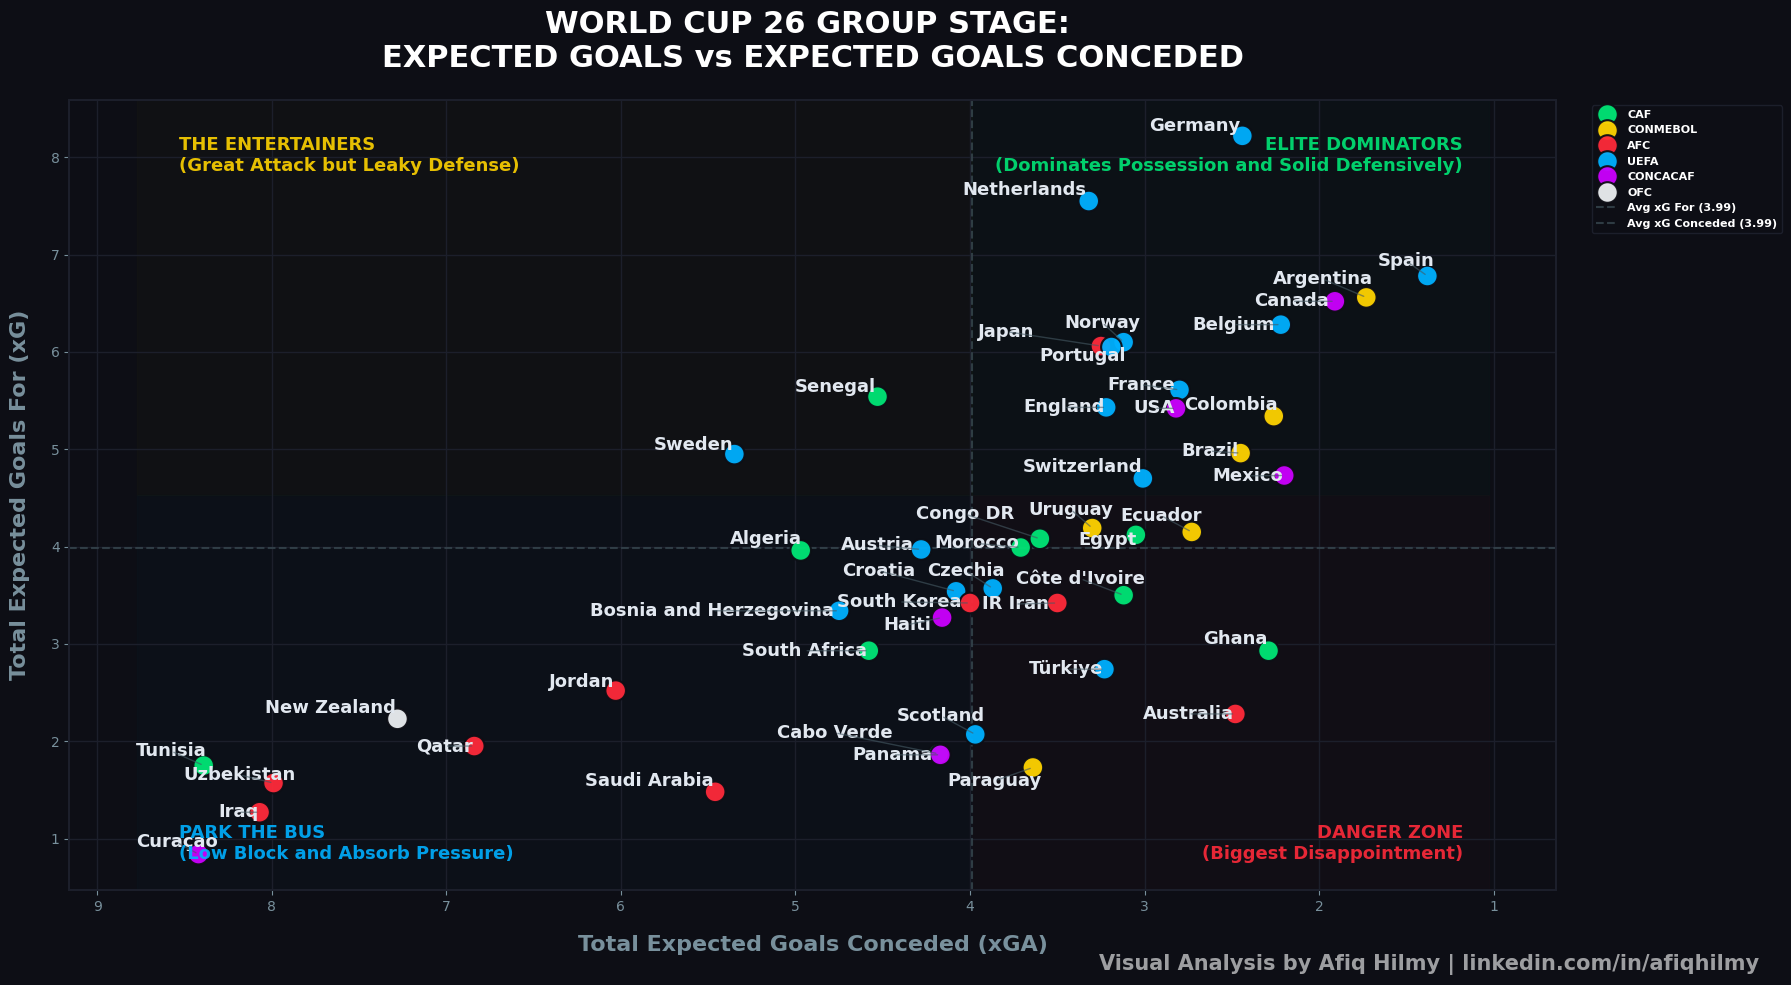

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# --- 1. SET FUTURISTIC DARK THEME AND COLOR PALETTE ---
# Deep cyber-space background color
bg_color = '#0D0E15'
grid_color = '#1C1F2B'
text_main = '#FFFFFF'
text_muted = '#78909C'

# Custom neon/vibrant palette tailored to World Cup 2026 host vibes
wc26_palette = {
    'UEFA': '#00B0FF',       # Electric Blue
    'CONMEBOL': '#FFD300',   # Radiant Gold
    'AFC': '#FF2A3A',        # Neon Torch Red
    'CAF': '#00E676',        # Cyber Pitch Green
    'CONCACAF': '#CC00FF',   # Neon Host Purple
    'OFC': '#ECEFF1'         # Platinum Silver
}

# Apply global dark mode theme parameters
plt.rcParams['figure.facecolor'] = bg_color
plt.rcParams['axes.facecolor'] = bg_color
plt.rcParams['text.color'] = text_main
plt.rcParams['axes.labelcolor'] = text_muted
plt.rcParams['xtick.color'] = text_muted
plt.rcParams['ytick.color'] = text_muted

# --- 2. INITIALIZE PLOT ---
plt.figure(figsize=(18, 10))

# Plot scatter points with an outer rim (edgecolor) so they pop off the dark background
sns.scatterplot(
    data=team_stats_summary,
    x='xga_y',
    y='xg',
    s=220,
    hue='team_confederation',
    palette=wc26_palette,
    edgecolor='#0D0E15',
    linewidth=1.5,
    alpha=0.95,
    zorder=3
)

# --- 3. ADVANCED TEXT LABELING ---
texts = []
for index, row in team_stats_summary.iterrows():
    texts.append(plt.text(
        row['xga_y'], row['xg'], row['team_name'],
        fontsize=13,
        fontfamily='Open Sans',
        fontweight='bold',
        color='#E2E8F0' # Crisp off-white for team names
    ))

# Adjust text to prevent overlapping with clean dark-gray indicator lines
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='#455A64', alpha=0.6, linewidth=1),
    expand_points=(1.5, 1.5)
)

# --- 4. HEADERS AND LABELS ---
plt.title('WORLD CUP 26 GROUP STAGE: \nEXPECTED GOALS vs EXPECTED GOALS CONCEDED',
          fontfamily='Open Sans', fontweight='bold', fontsize=22, pad=24, color=text_main, loc='center')

plt.xlabel('Total Expected Goals Conceded (xGA)', fontfamily='Open Sans', fontweight='bold', labelpad=15, fontsize=16)
plt.ylabel('Total Expected Goals For (xG)', fontfamily='Open Sans', fontweight='bold', labelpad=15, fontsize=16)

# --- 5. REFERENCE BENCHMARKS ---
avg_xg_for = team_stats_summary['xg'].mean()
avg_xg_against = team_stats_summary['xga_y'].mean() # Corrected column name

# Tactical grid division lines
plt.axhline(avg_xg_for, color='#37474F', linestyle='--', linewidth=1.5, alpha=0.8, zorder=2, label=f'Avg xG For ({avg_xg_for:.2f})')
plt.axvline(avg_xg_against, color='#37474F', linestyle='--', linewidth=1.5, alpha=0.8, zorder=2, label=f'Avg xG Conceded ({avg_xg_against:.2f})')

# Invert x-axis (Elite defensive metrics move to the right side)
plt.gca().invert_xaxis()

# Get dynamic bounds
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

# --- 6. FUTURISTIC QUADRANT BACKGROUND GLOWS & LABELS ---
# Subtle backing tints to map the 4 areas structurally without clutter
plt.gca().axvspan(xmin, avg_xg_against, ymin=0.5, ymax=1.0, color='#FFD300', alpha=0.015, zorder=1) # Top Right
plt.gca().axvspan(avg_xg_against, xmax, ymin=0.5, ymax=1.0, color='#00E676', alpha=0.015, zorder=1) # Top Left
plt.gca().axvspan(xmin, avg_xg_against, ymin=0.0, ymax=0.5, color='#00B0FF', alpha=0.015, zorder=1) # Bottom Right
plt.gca().axvspan(avg_xg_against, xmax, ymin=0.0, ymax=0.5, color='#FF2A3A', alpha=0.02, zorder=1)  # Bottom Left

# Quadrant Text Overlays
# Top Right: High xG, Low xGA (Elite Dominators) -> mapped to green zone
plt.text(xmax + (avg_xg_against-xmax)*0.05, ymax - (ymax-avg_xg_for)*0.08, 'ELITE DOMINATORS\n(Dominates Possession and Solid Defensively)',
         fontsize=13, fontfamily='Open Sans', color='#00E676', alpha=0.9, fontweight='bold', ha='right', va='top')

# Top Left: High xG, High xGA (The Entertainers) -> mapped to orange/yellow zone
plt.text(xmin - (xmin-avg_xg_against)*0.05, ymax - (ymax-avg_xg_for)*0.08, 'THE ENTERTAINERS\n(Great Attack but Leaky Defense)',
         fontsize=13, fontfamily='Open Sans', color='#FFD300', alpha=0.9, fontweight='bold', ha='left', va='top')

# Bottom Right: Low xG, Low xGA (Park The Bus) -> mapped to red zone
plt.text(xmax + (avg_xg_against-xmax)*0.05, ymin + (avg_xg_for-ymin)*0.08, 'DANGER ZONE\n(Biggest Disappointment)',
         fontsize=13, fontfamily='Open Sans', color='#FF2A3A', alpha=0.9, fontweight='bold', ha='right', va='bottom')

# Bottom Left: Low xG, High xGA (Danger Zone) -> mapped to blue zone
plt.text(xmin - (xmin-avg_xg_against)*0.05, ymin + (avg_xg_for-ymin)*0.08, 'PARK THE BUS\n(Low Block and Absorb Pressure)',
         fontsize=13, fontfamily='Open Sans', color='#00B0FF', alpha=0.9, fontweight='bold', ha='left', va='bottom')

# --- 7. GRID & LEGEND CUSTOMIZATION ---
plt.grid(True, linestyle='-', color=grid_color, linewidth=1, zorder=0)

# Custom legend positioning with transparent framing against the canvas background
plt.legend(
    prop={'family': 'Open Sans', 'weight': 'bold', 'size': 8},
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    facecolor=bg_color,
    edgecolor=grid_color,
    framealpha=1
)

# Smooth spine border modifications to match image_a971eb.jpg framework cleanly
for spine in plt.gca().spines.values():
    spine.set_color(grid_color)
    spine.set_linewidth(1.5)

# --- 8. PROFESSIONAL PORTFOLIO WATERMARK ---
# Uses figure coordinates (transform=plt.gcf().transFigure) to anchor it perfectly at the bottom right
plt.text(
    0.98, 0.02,                                    # X and Y positions on the canvas (0.0 to 1.0)
    'Visual Analysis by Afiq Hilmy | linkedin.com/in/afiqhilmy',
    transform=plt.gcf().transFigure,              # Binds the placement to the overall window, not the data
    fontsize=15,
    fontfamily='Open Sans',
    fontweight='bold',
    color='white',                               # Subtle gray-blue that blends cleanly into your dark mode theme
    ha='right',                                    # Aligns the text to the right edge
    va='bottom',                                   # Aligns the text to the bottom edge
    alpha=0.6                                      # Slight transparency so it looks like a true watermark
)
plt.tight_layout()
plt.show()

## xG vs Goals

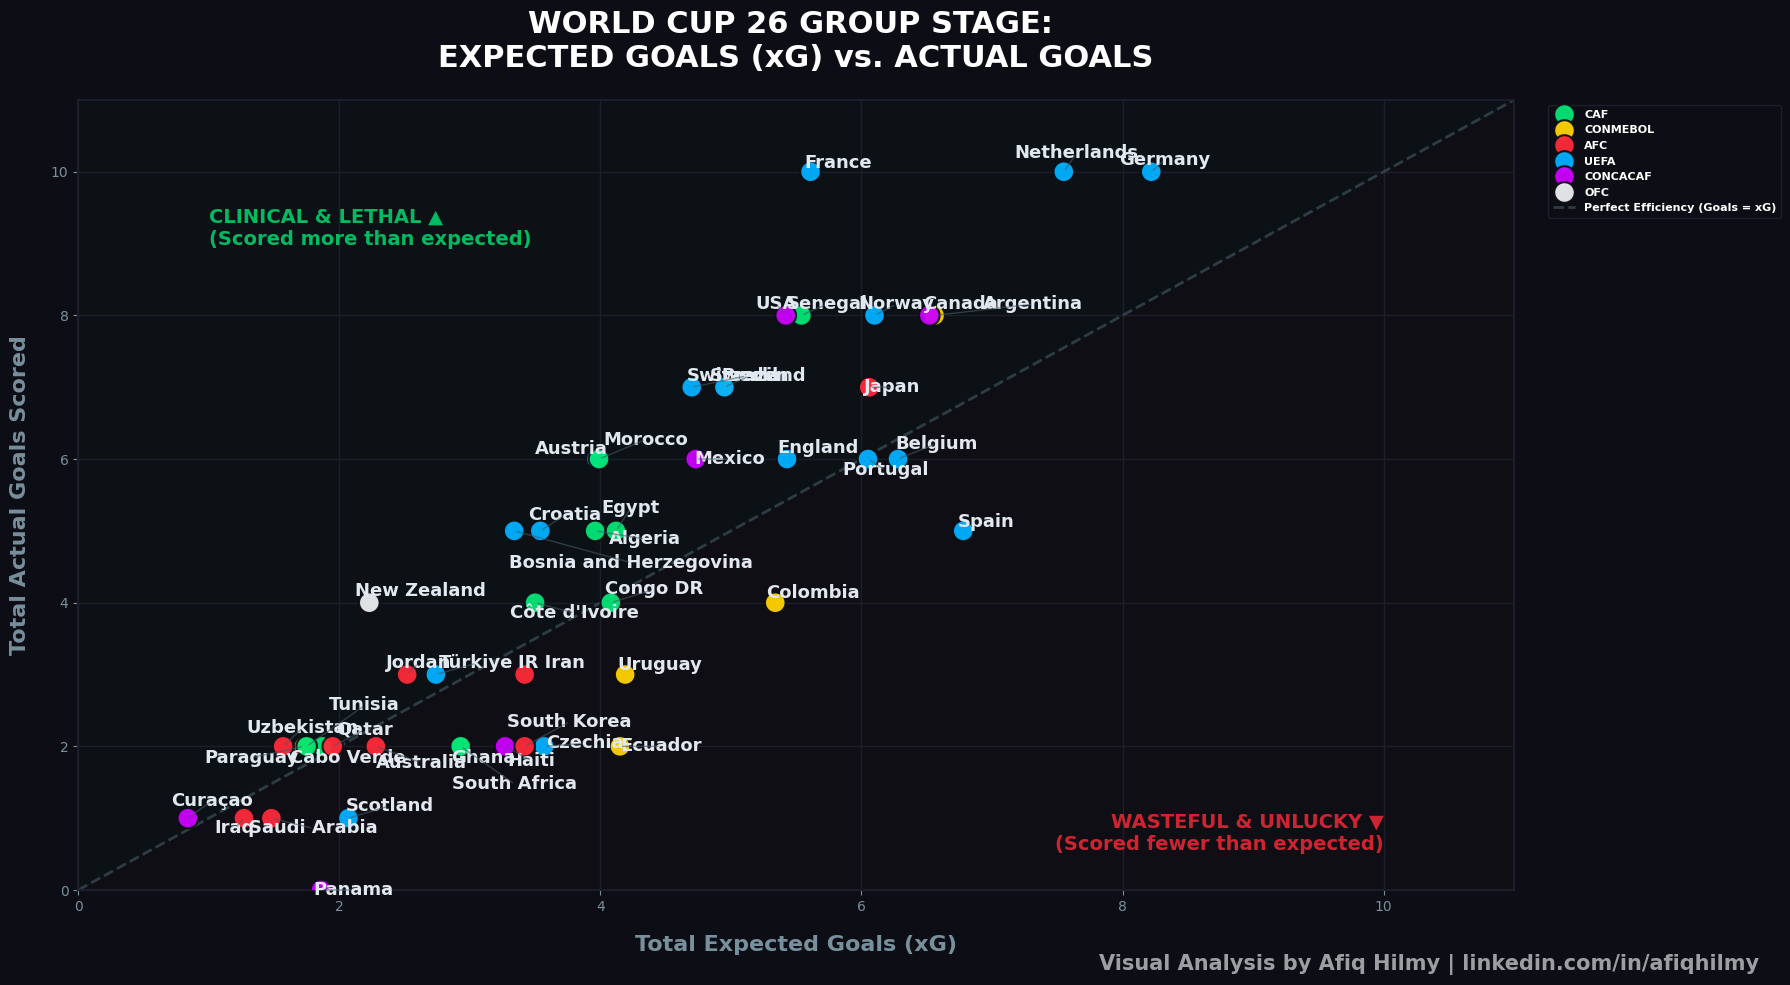

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# --- 1. SET FUTURISTIC DARK THEME AND COLOR PALETTE ---
# Deep cyber-space background color
bg_color = '#0D0E15'
grid_color = '#1C1F2B'
text_main = '#FFFFFF'
text_muted = '#78909C'

# Custom neon/vibrant palette tailored to World Cup 2026 host vibes
wc26_palette = {
    'UEFA': '#00B0FF',       # Electric Blue
    'CONMEBOL': '#FFD300',   # Radiant Gold
    'AFC': '#FF2A3A',        # Neon Torch Red
    'CAF': '#00E676',        # Cyber Pitch Green
    'CONCACAF': '#CC00FF',   # Neon Host Purple
    'OFC': '#ECEFF1'         # Platinum Silver
}

# Apply global dark mode theme parameters
plt.rcParams['figure.facecolor'] = bg_color
plt.rcParams['axes.facecolor'] = bg_color
plt.rcParams['text.color'] = text_main
plt.rcParams['axes.labelcolor'] = text_muted
plt.rcParams['xtick.color'] = text_muted
plt.rcParams['ytick.color'] = text_muted

# --- 2. INITIALIZE PLOT ---
plt.figure(figsize=(18, 10))

# Plot scatter points with an outer rim (edgecolor) so they pop off the dark background
sns.scatterplot(
    data=team_stats_summary,
    x='xg',
    y='goals',
    s=220,
    hue='team_confederation',
    palette=wc26_palette,
    edgecolor='#0D0E15',
    linewidth=1.5,
    alpha=0.95,
    zorder=3
)

# --- 3. ADVANCED TEXT LABELING ---
texts = []
for index, row in team_stats_summary.iterrows():
    texts.append(plt.text(
        row['xg'], row['goals'], row['team_name'],
        fontsize=13,
        fontfamily='Open Sans',
        fontweight='bold',
        color='#E2E8F0' # Crisp off-white for team names
    ))

# Adjust text to prevent overlapping with clean dark-gray indicator lines
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='#455A64', alpha=0.6, linewidth=1),
    expand_points=(1.5, 1.5)
)

# --- 4. HEADERS AND LABELS ---
plt.title('WORLD CUP 26 GROUP STAGE: \nEXPECTED GOALS (xG) vs. ACTUAL GOALS',
          fontfamily='Open Sans', fontweight='bold', fontsize=22, pad=24, color=text_main, loc='center')

plt.xlabel('Total Expected Goals (xG)', fontfamily='Open Sans', fontweight='bold', labelpad=15, fontsize=16)
plt.ylabel('Total Actual Goals Scored', fontfamily='Open Sans', fontweight='bold', labelpad=15, fontsize=16)

# --- 5. THE DIAGONAL EFFICIENCY BENCHMARK ---
# Find the absolute maximum value across both axes to keep the diagonal perfect
max_val = max(team_stats_summary['xg'].max(), team_stats_summary['goals'].max()) + 1

# Draw the 45-degree identity line (Where Goals = xG)
plt.plot([0, max_val], [0, max_val], color='#455A64', linestyle='--', linewidth=2, alpha=0.6, zorder=2, label='Perfect Efficiency (Goals = xG)')

# Set the limits identically to make the diagonal a true 45-degree angle
plt.xlim(0, max_val)
plt.ylim(0, max_val)

# --- 6. TWO-ZONE BACKGROUND SHADING & TEXT OVERLAYS ---
# Instead of 4 quadrants, we shade above and below the diagonal line
# Top-Left Triangle: Overperforming xG
plt.gca().fill_between([0, max_val], [0, max_val], max_val, color='#00E676', alpha=0.015, zorder=1)
# Bottom-Right Triangle: Underperforming xG
plt.gca().fill_between([0, max_val], 0, [0, max_val], color='#FF2A3A', alpha=0.015, zorder=1)

# Clean, directional text overlays
plt.text(1.0, max_val - 1.5, 'CLINICAL & LETHAL ▲\n(Scored more than expected)',
         fontsize=14, fontfamily='Open Sans', color='#00E676', alpha=0.8, fontweight='bold', ha='left', va='top')

plt.text(max_val - 1.0, 0.5, 'WASTEFUL & UNLUCKY ▼\n(Scored fewer than expected)',
         fontsize=14, fontfamily='Open Sans', color='#FF2A3A', alpha=0.8, fontweight='bold', ha='right', va='bottom')

# --- 7. GRID & LEGEND CUSTOMIZATION ---
plt.grid(True, linestyle='-', color=grid_color, linewidth=1, zorder=0)

# Custom legend positioning with transparent framing against the canvas background
plt.legend(
    prop={'family': 'Open Sans', 'weight': 'bold', 'size': 8},
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    facecolor=bg_color,
    edgecolor=grid_color,
    framealpha=1
)

# Smooth spine border modifications to match image_a971eb.jpg framework cleanly
for spine in plt.gca().spines.values():
    spine.set_color(grid_color)
    spine.set_linewidth(1.5)

# --- 8. PROFESSIONAL PORTFOLIO WATERMARK ---
# Uses figure coordinates (transform=plt.gcf().transFigure) to anchor it perfectly at the bottom right
plt.text(
    0.98, 0.02,                                    # X and Y positions on the canvas (0.0 to 1.0)
    'Visual Analysis by Afiq Hilmy | linkedin.com/in/afiqhilmy',
    transform=plt.gcf().transFigure,              # Binds the placement to the overall window, not the data
    fontsize=15,
    fontfamily='Open Sans',
    fontweight='bold',
    color='white',                               # Subtle gray-blue that blends cleanly into your dark mode theme
    ha='right',                                    # Aligns the text to the right edge
    va='bottom',                                   # Aligns the text to the bottom edge
    alpha=0.6                                      # Slight transparency so it looks like a true watermark
)

plt.tight_layout()
plt.show()

## xGA vs Goals Conceded

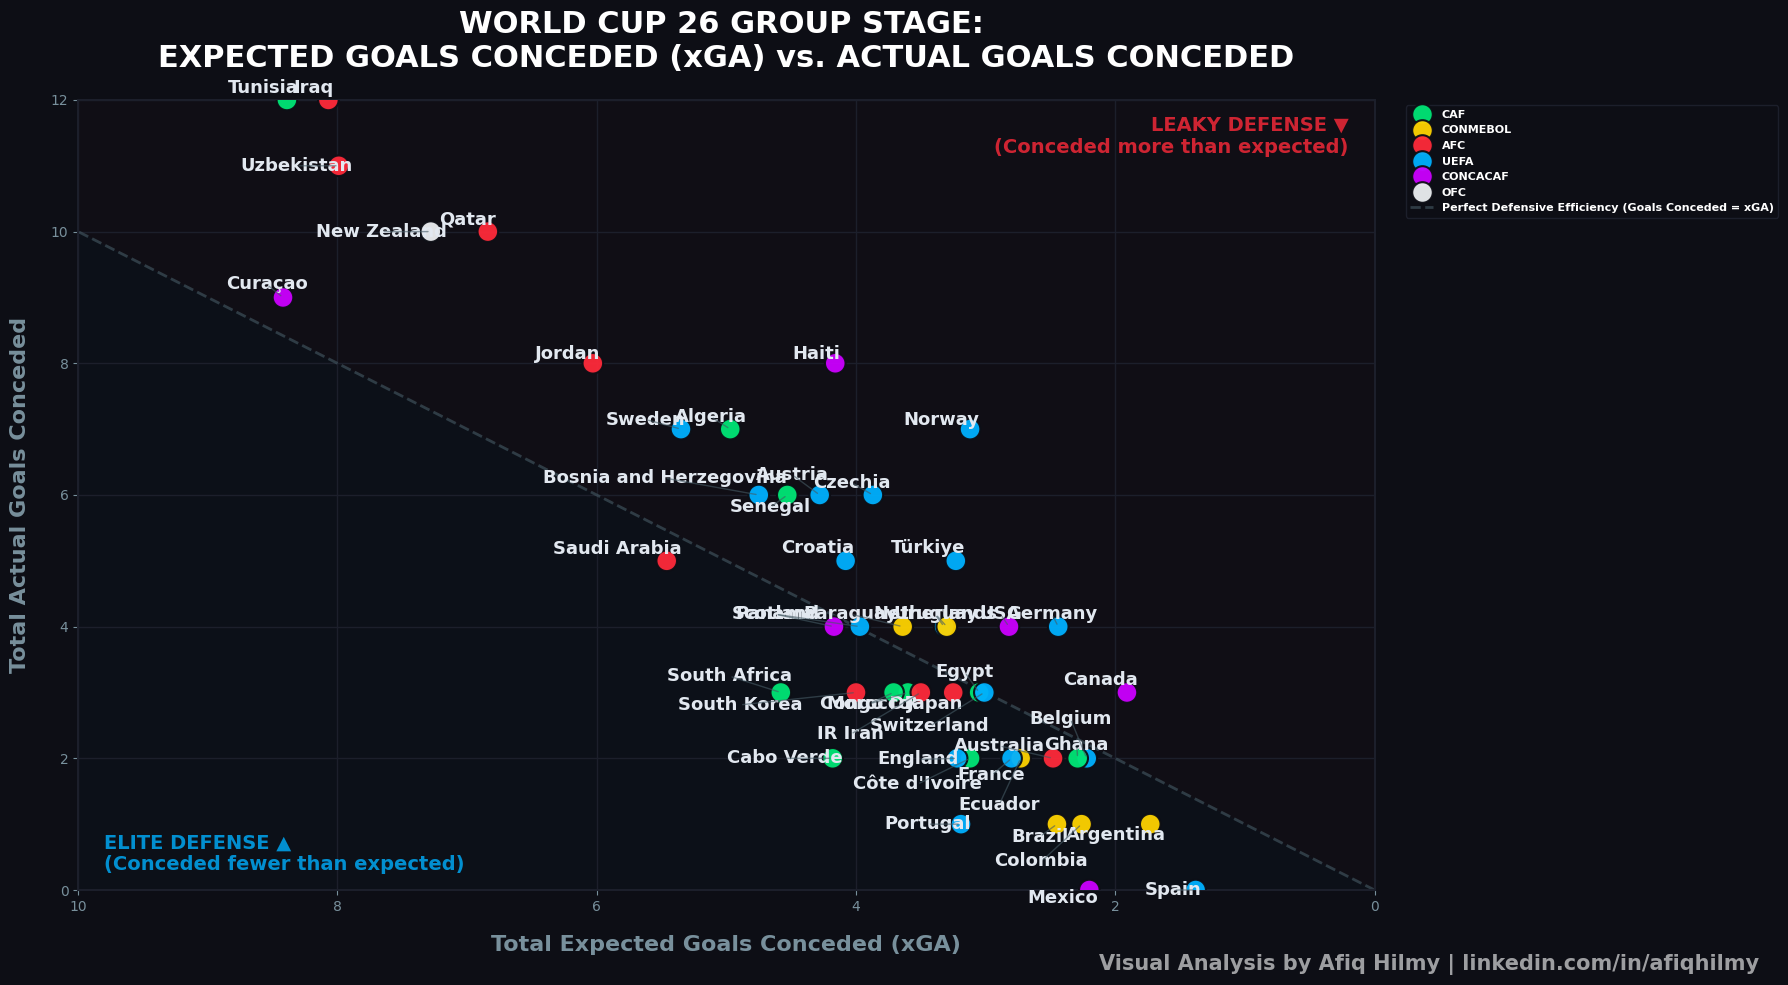

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# --- 1. SET FUTURISTIC DARK THEME AND COLOR PALETTE ---
# Deep cyber-space background color
bg_color = '#0D0E15'
grid_color = '#1C1F2B'
text_main = '#FFFFFF'
text_muted = '#78909C'

# Custom neon/vibrant palette tailored to World Cup 2026 host vibes
wc26_palette = {
    'UEFA': '#00B0FF',       # Electric Blue
    'CONMEBOL': '#FFD300',   # Radiant Gold
    'AFC': '#FF2A3A',        # Neon Torch Red
    'CAF': '#00E676',        # Cyber Pitch Green
    'CONCACAF': '#CC00FF',   # Neon Host Purple
    'OFC': '#ECEFF1'         # Platinum Silver
}

# Apply global dark mode theme parameters
plt.rcParams['figure.facecolor'] = bg_color
plt.rcParams['axes.facecolor'] = bg_color
plt.rcParams['text.color'] = text_main
plt.rcParams['axes.labelcolor'] = text_muted
plt.rcParams['xtick.color'] = text_muted
plt.rcParams['ytick.color'] = text_muted

# --- 2. INITIALIZE PLOT ---
plt.figure(figsize=(18,10)) # Increased figure size

# Plot scatter points with an outer rim (edgecolor) so they pop off the dark background
sns.scatterplot(
    data=team_stats_summary,
    x='xga_y',
    y='goals_conceded_y',
    s=220,
    hue='team_confederation',
    palette=wc26_palette,
    edgecolor='#0D0E15',
    linewidth=1.5,
    alpha=0.95,
    zorder=3
)

# --- 3. ADVANCED TEXT LABELING ---
texts = []
for index, row in team_stats_summary.iterrows():
    texts.append(plt.text(
        row['xga_y'], row['goals_conceded_y'], row['team_name'],
        fontsize=13,
        fontfamily='Open Sans',
        fontweight='bold',
        color='#E2E8F0' # Crisp off-white for team names
    ))

# Adjust text to prevent overlapping with clean dark-gray indicator lines
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='#455A64', alpha=0.6, linewidth=1),
    expand_points=(2.0, 2.0) # Increased expand_points
)

# --- 4. HEADERS AND LABELS ---
plt.title('WORLD CUP 26 GROUP STAGE: \nEXPECTED GOALS CONCEDED (xGA) vs. ACTUAL GOALS CONCEDED',
          fontfamily='Open Sans', fontweight='bold', fontsize=22, pad=24, color=text_main, loc='center')

plt.xlabel('Total Expected Goals Conceded (xGA)', fontfamily='Open Sans', fontweight='bold', labelpad=15, fontsize=16)
plt.ylabel('Total Actual Goals Conceded', fontfamily='Open Sans', fontweight='bold', labelpad=15, fontsize=16)

# --- 5. THE DIAGONAL EFFICIENCY BENCHMARK ---
# Find the absolute maximum value across both axes to keep the diagonal perfect
max_val = max(team_stats_summary['xga_y'].max(), team_stats_summary['goals_conceded_y'].max())

# Invert x-axis (Lower xGA is better defensively, so it should be on the right)
plt.gca().invert_xaxis()

# Draw the 45-degree identity line (Where Goals Conceded = xGA)
plt.plot([0, max_val], [0, max_val], color='#455A64', linestyle='--', linewidth=2, alpha=0.6, zorder=2, label='Perfect Defensive Efficiency (Goals Conceded = xGA)')

# Set the limits identically to make the diagonal a true 45-degree angle
# Note: xlim will be inverted here due to invert_xaxis()
plt.xlim(10, 0) # Set max_val as the left limit, 0 as the right limit
plt.ylim(0, max_val)

# Get dynamic bounds after inversion
x_min_current, x_max_current = plt.xlim() # x_min_current will be the larger value (left side), x_max_current will be the smaller value (right side)
y_min_current, y_max_current = plt.ylim()

# --- 6. TWO-ZONE BACKGROUND SHADING & TEXT OVERLAYS ---
# Instead of 4 quadrants, we shade above and below the diagonal line (y=x)

# Zone 1: Goals Conceded > xGA (Unlucky/Leaky Defense) - Visually above the diagonal
plt.gca().fill_between([0, max_val], [0, max_val], max_val, color='#FF2A3A', alpha=0.015, zorder=1)
# Zone 2: Goals Conceded < xGA (Elite/Lucky Defense) - Visually below the diagonal
plt.gca().fill_between([0, max_val], 0, [0, max_val], color='#00B0FF', alpha=0.015, zorder=1)

# Clean, directional text overlays, adjusted for inverted x-axis
# Top-Right (Low xGA, High Goals Conceded) - Leaky Defense
plt.text(x_max_current + (x_min_current - x_max_current) * 0.02, y_max_current - (y_max_current - y_min_current) * 0.02, 'LEAKY DEFENSE ▼\n(Conceded more than expected)',
         fontsize=14, fontfamily='Open Sans', color='#FF2A3A', alpha=0.8, fontweight='bold', ha='right', va='top')

# Bottom-Left (High xGA, Low Goals Conceded) - Elite Defense
plt.text(x_min_current - (x_min_current - x_max_current) * 0.02, y_min_current + (y_max_current - y_min_current) * 0.02, 'ELITE DEFENSE ▲\n(Conceded fewer than expected)',
         fontsize=14, fontfamily='Open Sans', color='#00B0FF', alpha=0.8, fontweight='bold', ha='left', va='bottom')

# --- 7. GRID & LEGEND CUSTOMIZATION ---
plt.grid(True, linestyle='-', color=grid_color, linewidth=1, zorder=0)

# Custom legend positioning with transparent framing against the canvas background
plt.legend(
    prop={'family': 'Open Sans', 'weight': 'bold', 'size': 8},
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    facecolor=bg_color,
    edgecolor=grid_color,
    framealpha=1
)

# Smooth spine border modifications to match image_a971eb.jpg framework cleanly
for spine in plt.gca().spines.values():
    spine.set_color(grid_color)
    spine.set_linewidth(1.5)

# --- 8. PROFESSIONAL PORTFOLIO WATERMARK ---
# Uses figure coordinates (transform=plt.gcf().transFigure) to anchor it perfectly at the bottom right
plt.text(
    0.98, 0.02,                                    # X and Y positions on the canvas (0.0 to 1.0)
    'Visual Analysis by Afiq Hilmy | linkedin.com/in/afiqhilmy',
    transform=plt.gcf().transFigure,              # Binds the placement to the overall window, not the data
    fontsize=15,
    fontfamily='Open Sans',
    fontweight='bold',
    color='white',                               # Subtle gray-blue that blends cleanly into your dark mode theme
    ha='right',                                    # Aligns the text to the right edge
    va='bottom',                                   # Aligns the text to the bottom edge
    alpha=0.6                                      # Slight transparency so it looks like a true watermark
)

plt.tight_layout()
plt.show()

1) xg vs xga

- Many teams from europe falls under dominators category
- AFC countries often challenged and dominated, indicating some levels below other federations

2) xg vs goals

- France, Netherlands and Germany are the most efficient teams in the group stage
- Some footballing giants like Spain and Portugal are unlucky and often miss their chances

3) xga vs goals conceded
- Spain and Mexico did not concede any goal in 3 games despite their xGA
- South Korea and Iran imbalance between good defense and weak attack cause them to be eliminated

